# 02 — Mock detections and mock parameter estimation

In this notebook we take the intrinsic population from notebook 01 and build a mock observed catalog.

This notebook introduces:

- a simple SNR model;
- a Finn--Chernoff orientation factor;
- a detection threshold;
- mock posterior samples for each detected event;
- detected injections for the selection correction.

The parameter-estimation samples passed to the hierarchical inference are stored in the physical variables

$
m_{1,z},\quad m_{2,z},\quad d_L,\quad \tilde{\Lambda}.
$

The mock PE prior is flat in detector-frame component masses, proportional to $ d_L^2$, and flat in $\tilde{\Lambda}$.


## Colab setup

If running on Colab, first clone the repository and enter it. If running locally from the repository root, skip this cell.


In [1]:
# Run this cell only on Colab.
# !git clone https://github.com/Mik3M4n/ns-eos-population-tutorial.git
# %cd ns-eos-population-tutorial
# !pip install -r requirements.txt


## Imports and paths


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

from astropy.cosmology import Planck18 as cosmology
from astropy.constants import c

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

processed_dir = project_root / "data/processed"
figures_dir = project_root / "figures"

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

C_KM_S = c.to("km/s").value


## Load intrinsic population from notebook 01


In [3]:
population_filename = "intrinsic_population__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993.npz"
pop = np.load(processed_dir / population_filename)

def npz_string(npz_file, key):
    return str(npz_file[key].item())

eos_tag = npz_string(pop, "eos_tag")
eos_base_tag = npz_string(pop, "eos_base_tag")
fit_mass_tag = npz_string(pop, "fit_mass_tag")
pop_tag = npz_string(pop, "pop_tag")

m1 = pop["m1"]
m2 = pop["m2"]
z = pop["z"]
d_l = pop["d_l"]
m1_det = pop["m1_det"]
m2_det = pop["m2_det"]
lambda1 = pop["lambda1"]
lambda2 = pop["lambda2"]
lambda_tilde = pop["lambda_tilde"]

m_min_true = float(pop["m_min_true"])
m_max_true = float(pop["m_max_true"])
alpha_z = float(pop["alpha_z"])
beta_z = float(pop["beta_z"])
z_p = float(pop["z_p"])



n_intrinsic = len(m1)

print(f"Loaded {n_intrinsic} intrinsic events from {population_filename}")
print(f"EOS tag: {eos_tag}")
print(f"Population tag: {pop_tag}")
print(f"Mass support: {m_min_true:.3f} -- {m_max_true:.3f} Msun")
print(f"Intrinsic redshift range: {z.min():.3f} -- {z.max():.3f}")


Loaded 100000 intrinsic events from intrinsic_population__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993.npz
EOS tag: bsk24_m1p00_2p25_poly5
Population tag: smoothbox_md_z20_n100000_seed31031993
Mass support: 1.000 -- 2.250 Msun
Intrinsic redshift range: 0.049 -- 19.957


## Main choices

The most important choices are collected here.

The detector sensitivity is controlled by `rho_ref`: a source with detector-frame chirp mass `mchirp_ref` at distance `d_l_ref` has optimal SNR `rho_ref`.

The catalog size is controlled independently by `target_n_detected`. This represents observing time, not detector sensitivity.


In [4]:
seed = 1871
rng = np.random.default_rng(seed)

# Observed catalog size.
target_n_detected = 100

# Number of posterior samples per detected event.
n_pe_samples = 5000

# Simple SNR normalization.
rho_ref = 80.0
mchirp_ref = 1.4       # Msun
d_l_ref = 1000.0       # Mpc
rho_threshold = 8.0

# PE uncertainty scale.
rho_error_ref = 12.0
sigma_log_mchirp_ref = 0.02
sigma_eta_ref = 0.02
sigma_log_dl_ref = 0.30
sigma_log_lambdatilde_ref = 0.50

# Injection settings for the selection correction.
n_inj_drawn = 200_000
z_draw_max = 20.0
inj_edge_width = 0.001
inj_edge_pdf_value = 1e-10

m_min_inj = 0.7
m_max_inj = 2.278
alpha_z_inj = 0.
beta_z_inj = 2.
z_p_inj = 1.

def number_tag(x):
    x = float(x)
    if x.is_integer():
        return str(int(x))
    return f"{x:g}".replace(".", "p").replace("-", "m")

detpe_tag = (
    f"det_rho{number_tag(rho_ref)}"
    f"_thr{number_tag(rho_threshold)}"
    f"_nev{target_n_detected}"
    f"_pe{n_pe_samples}"
    f"_seed{seed}"
)

inj_tag = (
    f"inj_n{n_inj_drawn}"
    f"_z{number_tag(z_draw_max)}"
    f"_edge{number_tag(inj_edge_width)}"
    f"_seed{seed}"
)

print(f"Detection/PE tag: {detpe_tag}")
print(f"Injection tag: {inj_tag}")


Detection/PE tag: det_rho80_thr8_nev100_pe5000_seed1871
Injection tag: inj_n200000_z20_edge0p001_seed1871


## Useful transformations

We will use detector-frame chirp mass and symmetric mass ratio,

$ \mathcal{M}_z = \frac{(m_{1,z}m_{2,z})^{3/5}}{(m_{1,z}+m_{2,z})^{1/5}}, $

$ \eta = \frac{m_{1,z}m_{2,z}}{(m_{1,z}+m_{2,z})^2}. $

Given $\mathcal{M}_z$ and $\eta$, the total detector-frame mass is

$ M_z = \mathcal{M}_z\,\eta^{-3/5}, $

and

$ m_{1,z} = \frac{M_z}{2}\left(1+\sqrt{1-4\eta}\right), \qquad m_{2,z} = \frac{M_z}{2}\left(1-\sqrt{1-4\eta}\right). $


In [5]:
def chirp_mass(m1, m2):
    return (m1 * m2) ** (3.0 / 5.0) / (m1 + m2) ** (1.0 / 5.0)

def symmetric_mass_ratio(m1, m2):
    return m1 * m2 / (m1 + m2) ** 2

def masses_from_logmchirp_eta(log_mchirp, eta):
    mchirp = np.exp(log_mchirp)
    total_mass = mchirp * eta ** (-3.0 / 5.0)
    delta = np.sqrt(1.0 - 4.0 * eta)
    m1 = 0.5 * total_mass * (1.0 + delta)
    m2 = 0.5 * total_mass * (1.0 - delta)
    return m1, m2

def lambda_tilde_from_components(m1, m2, lambda1, lambda2):
    return (16.0 / 13.0) * (
        (m1 + 12.0 * m2) * m1**4 * lambda1
        + (m2 + 12.0 * m1) * m2**4 * lambda2
    ) / (m1 + m2) ** 5

def ddL_dz(z):
    dc = cosmology.comoving_distance(z).value
    Hz = cosmology.H(z).value
    return dc + (1.0 + z) * C_KM_S / Hz


## Orientation factor and SNR model

We follow the mock-observation logic used in GWMockCat, described in Appendix A of Farah et al. (2023). The SNR is separated into an optimal SNR and a projection factor:

$ \rho_{\rm true}=w\rho_{\rm opt}. $

The optimal SNR is modeled as

$ \rho_{\rm opt} = \rho_{\rm ref} \left( \frac{\mathcal{M}_{z}}{\mathcal{M}_{z,\rm ref}} \right)^{5/6} \left( \frac{d_{L,\rm ref}}{d_L} \right). $

The constants $\rho_{\rm ref}$, $\mathcal{M}_{z,\rm ref}$, and $d_{L,\rm ref}$ define the normalization.

### Finn--Chernoff projection factor

Finn & Chernoff (1993) derive the single-interferometer projection-factor distribution for randomly located and oriented binaries. In their convention,

$ 0 < \Theta_{\rm FC} < 4 $

and

$ p(\Theta_{\rm FC}) = \frac{5}{256}\, \Theta_{\rm FC} \left(4-\Theta_{\rm FC}\right)^3 . $

We use the normalized projection factor

$ w=\frac{\Theta_{\rm FC}}{4}, \qquad 0<w<1. $

By change of variables,

$ p(w) = p(4w)\,4 = \frac{5}{256} (4w) (4-4w)^3 4 = 20w(1-w)^3. $

This is a Beta distribution,

$ w\sim{\rm Beta}(2,4). $

Finally, following GWMockCat, we add unit Gaussian noise to the true SNR,

$ \rho_{\rm obs}\sim \mathcal{N}(\rho_{\rm true},1), $

and detect events with

$ \rho_{\rm obs}>\rho_{\rm threshold}. $

References:

- Finn & Chernoff, Observing binary inspiral in gravitational radiation: One interferometer, Phys. Rev. D 47, 2198 (1993).
- Farah et al., Things that might go bump in the night: Assessing structure in the binary black hole mass spectrum, Appendix A, arXiv:2301.00834.


In [6]:
def snr_model(mchirp_det, d_l, w):
    rho_opt = rho_ref * (mchirp_det / mchirp_ref) ** (5.0 / 6.0) * (d_l_ref / d_l)
    rho_true = w * rho_opt
    return rho_opt, rho_true


## Detect a mock catalog


In [7]:
mchirp_det = chirp_mass(m1_det, m2_det)
eta = symmetric_mass_ratio(m1_det, m2_det)

w = rng.beta(2.0, 4.0, size=n_intrinsic)
rho_opt, rho_true = snr_model(mchirp_det, d_l, w)
rho_obs = rng.normal(rho_true, 1.0)

detected_mask = rho_obs > rho_threshold
detected_indices_all = np.where(detected_mask)[0]
n_detected_available = len(detected_indices_all)

print(f"Events above threshold: {n_detected_available}")
print(f"Target detected events: {target_n_detected}")

if n_detected_available < target_n_detected:
    raise ValueError("Too few detections. Increase rho_ref, n_events in notebook 01, or lower target_n_detected.")

selected_indices = rng.choice(detected_indices_all, size=target_n_detected, replace=False)
selected_indices = np.sort(selected_indices)

print(f"Selected {len(selected_indices)} detected events")


Events above threshold: 12541
Target detected events: 100
Selected 100 detected events


## Mock PE model

For each detected event, we make a Gaussian mock likelihood in

$ \log \mathcal{M}_z,\quad \eta,\quad \log d_L,\quad \log \tilde{\Lambda}. $

The widths scale as

$ \sigma_x = \sigma_{x,\rm ref} \frac{\rho_{\rm error,ref}}{\rho_{\rm obs}}. $

We want the final PE samples to correspond to a PE prior that is flat in detector-frame component masses, proportional to $d_L^2$, and flat in $\tilde{\Lambda}$:

$ \pi_{\rm PE}(m_{1,z},m_{2,z},d_L,\tilde{\Lambda})
\propto d_L^2. $

The Gaussian proposal is in

$ y=(\log\mathcal M_z,\eta,\log d_L,\log\tilde\Lambda). $

Therefore, in these coordinates, the prior factor is

$ \pi_{\rm PE}(y) \propto d_L^2 \left|
\frac{\partial(m_{1,z},m_{2,z},d_L,\tilde{\Lambda})}
{\partial(\log\mathcal M_z,\eta,\log d_L,\log\tilde\Lambda)} \right|. $

The distance and tidal parts give

$ \frac{\partial d_L}{\partial\log d_L}=d_L, \qquad \frac{\partial\tilde{\Lambda}}{\partial\log\tilde{\Lambda}} =\tilde{\Lambda}. $

For the mass part,

$ \left| \frac{\partial(m_{1,z},m_{2,z})}{\partial(\log\mathcal M_z,\eta)} \right| = \frac{M_z^2}{\sqrt{1-4\eta}}. $

So, up to an irrelevant constant,

$ \log \pi_{\rm PE}(y) = 3\log d_L + \log\tilde{\Lambda} + 2\log M_z - \frac{1}{2}\log(1-4\eta). $

We use rejection sampling to turn the Gaussian likelihood proposal into posterior samples with this PE prior. The samples saved for later inference are the physical variables

$ m_{1,z},\quad m_{2,z},\quad d_L,\quad \tilde{\Lambda}. $


In [8]:
eta_margin = 1e-5
eta_min = 0.01
proposal_nsigma = 5.0

def log_pe_prior_y(log_mchirp, eta, log_d_l, log_lambda_tilde):
    log_total_mass = log_mchirp - (3.0 / 5.0) * np.log(eta)
    return (
        3.0 * log_d_l
        + log_lambda_tilde
        + 2.0 * log_total_mass
        - 0.5 * np.log(1.0 - 4.0 * eta)
    )


# unused for now 
def draw_mock_pe_samples(y_obs, sigmas, n_samples):
    logmc_obs, eta_obs, logdl_obs, loglt_obs = y_obs
    sig_logmc, sig_eta, sig_logdl, sig_loglt = sigmas

    logmc_low = logmc_obs - proposal_nsigma * sig_logmc
    logmc_high = logmc_obs + proposal_nsigma * sig_logmc
    eta_low = max(eta_min, eta_obs - proposal_nsigma * sig_eta)
    eta_high = min(0.25 - eta_margin, eta_obs + proposal_nsigma * sig_eta)
    logdl_low = logdl_obs - proposal_nsigma * sig_logdl
    logdl_high = logdl_obs + proposal_nsigma * sig_logdl
    loglt_low = loglt_obs - proposal_nsigma * sig_loglt
    loglt_high = loglt_obs + proposal_nsigma * sig_loglt

    eta_grid = np.linspace(eta_low, eta_high, 2000)
    log_prior_bound = np.max(
        log_pe_prior_y(logmc_high, eta_grid, logdl_high, loglt_high)
    )

    samples = []
    while len(samples) < n_samples:
        batch = max(4 * (n_samples - len(samples)), 2000)

        logmc = rng.normal(logmc_obs, sig_logmc, size=batch)
        eta_prop = rng.normal(eta_obs, sig_eta, size=batch)
        logdl = rng.normal(logdl_obs, sig_logdl, size=batch)
        loglt = rng.normal(loglt_obs, sig_loglt, size=batch)

        in_bounds = (
            (logmc > logmc_low) & (logmc < logmc_high)
            & (eta_prop > eta_low) & (eta_prop < eta_high)
            & (logdl > logdl_low) & (logdl < logdl_high)
            & (loglt > loglt_low) & (loglt < loglt_high)
        )

        logmc = logmc[in_bounds]
        eta_prop = eta_prop[in_bounds]
        logdl = logdl[in_bounds]
        loglt = loglt[in_bounds]

        log_prior = log_pe_prior_y(logmc, eta_prop, logdl, loglt)
        accept_prob = np.exp(log_prior - log_prior_bound)

        if np.any(accept_prob > 1.0 + 1e-12):
            raise RuntimeError("PE rejection bound failed: acceptance probability exceeds 1.")
        accept_prob = np.minimum(accept_prob, 1.0)

        accept = rng.uniform(size=len(accept_prob)) < accept_prob

        accepted = np.column_stack([
            logmc[accept],
            eta_prop[accept],
            logdl[accept],
            loglt[accept],
        ])

        samples.extend(accepted.tolist())

    return np.array(samples[:n_samples])


## Generate mock observations and PE samples


In [9]:
idx = selected_indices

true_log_mchirp = np.log(mchirp_det[idx])
true_eta = eta[idx]
true_log_dl = np.log(d_l[idx])
true_log_lambdatilde = np.log(lambda_tilde[idx])

rho_obs_selected = rho_obs[idx]

sigma_log_mchirp = sigma_log_mchirp_ref * rho_error_ref / rho_obs_selected
sigma_eta = sigma_eta_ref * rho_error_ref / rho_obs_selected
sigma_log_dl = sigma_log_dl_ref * rho_error_ref / rho_obs_selected
sigma_log_lambdatilde = sigma_log_lambdatilde_ref * rho_error_ref / rho_obs_selected

obs_log_mchirp = rng.normal(true_log_mchirp, sigma_log_mchirp)
obs_eta = rng.normal(true_eta, sigma_eta)
obs_log_dl = rng.normal(true_log_dl, sigma_log_dl)
obs_log_lambdatilde = rng.normal(true_log_lambdatilde, sigma_log_lambdatilde)

valid_eta = (obs_eta > eta_min) & (obs_eta < 0.25 - eta_margin)
while not np.all(valid_eta):
    obs_eta[~valid_eta] = rng.normal(true_eta[~valid_eta], sigma_eta[~valid_eta])
    valid_eta = (obs_eta > eta_min) & (obs_eta < 0.25 - eta_margin)


# Importance-resampling PE generation.
#
# Proposal:
#   Gaussian mock likelihood in
#   (log Mchirp_z, eta, log d_L, log LambdaTilde).
#
# Target:
#   proposal times the desired PE prior in these coordinates.
#
# The desired PE prior is flat in detector-frame component masses,
# proportional to d_L^2, and flat in LambdaTilde.
# Therefore the prior factor in proposal coordinates is log_pe_prior_y.
pe_importance_factor = 10
n_proposals = pe_importance_factor * n_pe_samples

pe_log_mchirp = np.empty((target_n_detected, n_pe_samples))
pe_eta = np.empty((target_n_detected, n_pe_samples))
pe_log_d_l = np.empty((target_n_detected, n_pe_samples))
pe_log_lambda_tilde = np.empty((target_n_detected, n_pe_samples))

importance_ess = np.empty(target_n_detected)

for i in tqdm(range(target_n_detected), desc="Importance-resampling PE samples"):
    logmc_prop = rng.normal(obs_log_mchirp[i], sigma_log_mchirp[i], size=n_proposals)
    eta_prop = rng.normal(obs_eta[i], sigma_eta[i], size=n_proposals)
    logdl_prop = rng.normal(obs_log_dl[i], sigma_log_dl[i], size=n_proposals)
    loglt_prop = rng.normal(obs_log_lambdatilde[i], sigma_log_lambdatilde[i], size=n_proposals)

    in_bounds = (
        (eta_prop > eta_min)
        & (eta_prop < 0.25 - eta_margin)
    )

    logw = log_pe_prior_y(logmc_prop, eta_prop, logdl_prop, loglt_prop)
    logw = np.where(in_bounds, logw, -np.inf)

    max_logw = np.max(logw)
    weights = np.exp(logw - max_logw)
    weights /= np.sum(weights)

    importance_ess[i] = 1.0 / np.sum(weights**2)

    keep = rng.choice(
        n_proposals,
        size=n_pe_samples,
        replace=True,
        p=weights,
    )

    pe_log_mchirp[i] = logmc_prop[keep]
    pe_eta[i] = eta_prop[keep]
    pe_log_d_l[i] = logdl_prop[keep]
    pe_log_lambda_tilde[i] = loglt_prop[keep]

print("Importance-resampling ESS per event:")
print(f"  min = {importance_ess.min():.1f}")
print(f"  median = {np.median(importance_ess):.1f}")
print(f"  max = {importance_ess.max():.1f}")

pe_m1_det, pe_m2_det = masses_from_logmchirp_eta(pe_log_mchirp, pe_eta)
pe_d_l = np.exp(pe_log_d_l)
pe_lambda_tilde = np.exp(pe_log_lambda_tilde)

print(f"Generated PE samples with shape: {pe_m1_det.shape}")

Importance-resampling PE samples:   0%|          | 0/100 [00:00<?, ?it/s]

/var/folders/bz/qc_y_tmj1lv6v__5hy2s54x00000gn/T/ipykernel_44479/2014009027.py:11: RuntimeWarning: invalid value encountered in log
  - 0.5 * np.log(1.0 - 4.0 * eta)


Importance-resampling ESS per event:
  min = 617.1
  median = 5524.9
  max = 42561.6
Generated PE samples with shape: (100, 5000)


## Save detected catalog and PE samples


In [10]:
detected_output = processed_dir / f"detected_events__{eos_tag}__{pop_tag}__{detpe_tag}.npz"

np.savez(
    detected_output,
    eos_tag=eos_tag,
    eos_base_tag=eos_base_tag,
    fit_mass_tag=fit_mass_tag,
    pop_tag=pop_tag,
    detpe_tag=detpe_tag,
    population_filename=population_filename,
    seed=seed,
    target_n_detected=target_n_detected,
    rho_ref=rho_ref,
    mchirp_ref=mchirp_ref,
    d_l_ref=d_l_ref,
    rho_threshold=rho_threshold,
    orientation_model="finn_chernoff_beta_2_4",
    snr_model="rho_ref_mchirp_5over6_dL_inverse",
    rho_noise_model="normal_unit_sigma",
    selected_indices=selected_indices,
    m1=m1[idx],
    m2=m2[idx],
    z=z[idx],
    d_l=d_l[idx],
    m1_det=m1_det[idx],
    m2_det=m2_det[idx],
    mchirp_det=mchirp_det[idx],
    eta=eta[idx],
    lambda1=lambda1[idx],
    lambda2=lambda2[idx],
    lambda_tilde=lambda_tilde[idx],
    w=w[idx],
    rho_opt=rho_opt[idx],
    rho_true=rho_true[idx],
    rho_obs=rho_obs[idx],
)

pe_output = processed_dir / f"mock_pe_samples__{eos_tag}__{pop_tag}__{detpe_tag}.npz"

np.savez(
    pe_output,
    eos_tag=eos_tag,
    eos_base_tag=eos_base_tag,
    fit_mass_tag=fit_mass_tag,
    pop_tag=pop_tag,
    detpe_tag=detpe_tag,
    population_filename=population_filename,
    seed=seed,
    target_n_detected=target_n_detected,
    rho_ref=rho_ref,
    mchirp_ref=mchirp_ref,
    d_l_ref=d_l_ref,
    rho_threshold=rho_threshold,
    orientation_model="finn_chernoff_beta_2_4",
    snr_model="rho_ref_mchirp_5over6_dL_inverse",
    rho_noise_model="normal_unit_sigma",
    n_pe_samples=n_pe_samples,
    rho_error_ref=rho_error_ref,
    sigma_log_mchirp_ref=sigma_log_mchirp_ref,
    sigma_eta_ref=sigma_eta_ref,
    sigma_log_dl_ref=sigma_log_dl_ref,
    sigma_log_lambdatilde_ref=sigma_log_lambdatilde_ref,
    pe_likelihood_coordinates="log_mchirp_det,eta,log_d_l,log_lambda_tilde",
    pe_sample_coordinates="m1_det,m2_det,d_l,lambda_tilde",
    pe_prior="flat_m1det_m2det_flat_lambdatilde_dL2",
    true_log_mchirp=true_log_mchirp,
    true_eta=true_eta,
    true_log_dl=true_log_dl,
    true_log_lambdatilde=true_log_lambdatilde,
    obs_log_mchirp=obs_log_mchirp,
    obs_eta=obs_eta,
    obs_log_dl=obs_log_dl,
    obs_log_lambdatilde=obs_log_lambdatilde,
    sigma_log_mchirp=sigma_log_mchirp,
    sigma_eta=sigma_eta,
    sigma_log_dl=sigma_log_dl,
    sigma_log_lambdatilde=sigma_log_lambdatilde,
    m1_det=pe_m1_det,
    m2_det=pe_m2_det,
    d_l=pe_d_l,
    lambda_tilde=pe_lambda_tilde,
    log_mchirp=pe_log_mchirp,
    eta=pe_eta,
    log_d_l=pe_log_d_l,
    log_lambda_tilde=pe_log_lambda_tilde,
)

print(f"Saved detected catalog to {detected_output}")
print(f"Saved PE samples to {pe_output}")


Saved detected catalog to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/data/processed/detected_events__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.npz
Saved PE samples to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/data/processed/mock_pe_samples__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.npz


## Draw injections for the selection correction

The injections are drawn from a reference population. The mass support is the same EOS-valid interval as the true population, but the injection distribution is independently specified.

The injections are drawn internally in source-frame variables $(m_1,m_2,z)$, but the stored draw density is the density in detector-frame variables

$ (m_{1,z},m_{2,z},d_L). $

The transformation is

$ m_{1,z}=(1+z)m_1,\qquad m_{2,z}=(1+z)m_2,\qquad d_L=d_L(z). $

Therefore,

$ \log p_{\rm draw}(m_{1,z},m_{2,z},d_L) = \log p_{\rm draw}(m_1,m_2,z) -2\log(1+z) -\log\left(\frac{d d_L}{dz}\right). $

The orientation factor is not included in $p_{\rm draw}$. It is part of the detection process, not part of the astrophysical population density.


In [11]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def bounded_smooth_pdf(m, m_min, m_max, edge_width, edge_pdf_value):
    logit_edge = np.log((1.0 - edge_pdf_value) / edge_pdf_value)
    edge_scale = edge_width / logit_edge

    left = sigmoid((m - m_min - edge_width) / edge_scale)
    right = sigmoid((m_max - edge_width - m) / edge_scale)
    return left * right

def make_normalized_pdf(grid, pdf_unnormalized):
    norm = np.trapezoid(pdf_unnormalized, grid)
    return pdf_unnormalized / norm, norm

def merger_rate_density(z):
    numerator = (1.0 + z) ** alpha_z_inj
    denominator = 1.0 + ((1.0 + z) / (1.0 + z_p_inj)) ** (alpha_z_inj + beta_z_inj)
    return numerator / denominator

def redshift_pdf_unnormalized(z):
    dvc_dz = cosmology.differential_comoving_volume(z).value
    return merger_rate_density(z) * dvc_dz / (1.0 + z)

def draw_from_grid_pdf(grid, pdf, n):
    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (pdf[1:] + pdf[:-1]) * np.diff(grid))])
    cdf /= cdf[-1]
    u = rng.uniform(size=n)
    return np.interp(u, cdf, grid)


In [12]:
m_draw_min = m_min_inj
m_draw_max = m_max_inj

m_draw_grid = np.linspace(m_draw_min, m_draw_max, 10000)
p_m_draw_unnorm = bounded_smooth_pdf(
    m_draw_grid,
    m_draw_min,
    m_draw_max,
    inj_edge_width,
    inj_edge_pdf_value,
)
p_m_draw_grid, _ = make_normalized_pdf(m_draw_grid, p_m_draw_unnorm)

z_draw_grid = np.linspace(0.0, z_draw_max, 100000)
p_z_draw_unnorm = redshift_pdf_unnormalized(z_draw_grid)
p_z_draw_grid, _ = make_normalized_pdf(z_draw_grid, p_z_draw_unnorm)

inj_a = draw_from_grid_pdf(m_draw_grid, p_m_draw_grid, 2 * n_inj_drawn)
inj_a = inj_a.reshape(n_inj_drawn, 2)

inj_m1 = np.maximum(inj_a[:, 0], inj_a[:, 1])
inj_m2 = np.minimum(inj_a[:, 0], inj_a[:, 1])
inj_z = draw_from_grid_pdf(z_draw_grid, p_z_draw_grid, n_inj_drawn)

inj_d_l = cosmology.luminosity_distance(inj_z).value
inj_m1_det = inj_m1 * (1.0 + inj_z)
inj_m2_det = inj_m2 * (1.0 + inj_z)
inj_mchirp_det = chirp_mass(inj_m1_det, inj_m2_det)
inj_eta = symmetric_mass_ratio(inj_m1_det, inj_m2_det)

inj_lambda1 = np.exp(np.polyval(pop["eos_chosen_coeffs"], inj_m1))
inj_lambda2 = np.exp(np.polyval(pop["eos_chosen_coeffs"], inj_m2))
inj_lambda_tilde = lambda_tilde_from_components(inj_m1, inj_m2, inj_lambda1, inj_lambda2)

inj_w = rng.beta(2.0, 4.0, size=n_inj_drawn)
inj_rho_opt, inj_rho_true = snr_model(inj_mchirp_det, inj_d_l, inj_w)
inj_rho_obs = rng.normal(inj_rho_true, 1.0)
inj_detected = inj_rho_obs > rho_threshold

log_p_m1 = np.log(np.interp(inj_m1, m_draw_grid, p_m_draw_grid))
log_p_m2 = np.log(np.interp(inj_m2, m_draw_grid, p_m_draw_grid))
log_p_z = np.log(np.interp(inj_z, z_draw_grid, p_z_draw_grid))

log_p_draw_source = np.log(2.0) + log_p_m1 + log_p_m2 + log_p_z
log_p_draw_det = (
    log_p_draw_source
    - 2.0 * np.log1p(inj_z)
    - np.log(ddL_dz(inj_z))
)

print(f"Drawn injections: {n_inj_drawn}")
print(f"Detected injections: {inj_detected.sum()}")


Drawn injections: 200000
Detected injections: 41709


## Save detected injections


In [13]:
inj = inj_detected

injection_output = processed_dir / f"injections__{eos_tag}__{pop_tag}__{detpe_tag}__{inj_tag}.npz"

np.savez(
    injection_output,
    eos_tag=eos_tag,
    eos_base_tag=eos_base_tag,
    fit_mass_tag=fit_mass_tag,
    pop_tag=pop_tag,
    detpe_tag=detpe_tag,
    inj_tag=inj_tag,
    population_filename=population_filename,
    seed=seed,
    rho_ref=rho_ref,
    mchirp_ref=mchirp_ref,
    d_l_ref=d_l_ref,
    rho_threshold=rho_threshold,
    orientation_model="finn_chernoff_beta_2_4",
    snr_model="rho_ref_mchirp_5over6_dL_inverse",
    rho_noise_model="normal_unit_sigma",
    n_inj_drawn=n_inj_drawn,
    z_draw_max=z_draw_max,
    inj_edge_width=inj_edge_width,
    inj_edge_pdf_value=inj_edge_pdf_value,
    m_draw_min=m_draw_min,
    m_draw_max=m_draw_max,
    log_p_draw_coordinates="m1_det,m2_det,d_l",
    orientation_included_in_log_p_draw=False,
    m1=inj_m1[inj],
    m2=inj_m2[inj],
    z=inj_z[inj],
    d_l=inj_d_l[inj],
    m1_det=inj_m1_det[inj],
    m2_det=inj_m2_det[inj],
    mchirp_det=inj_mchirp_det[inj],
    eta=inj_eta[inj],
    lambda1=inj_lambda1[inj],
    lambda2=inj_lambda2[inj],
    lambda_tilde=inj_lambda_tilde[inj],
    w=inj_w[inj],
    rho_opt=inj_rho_opt[inj],
    rho_true=inj_rho_true[inj],
    rho_obs=inj_rho_obs[inj],
    log_p_draw=log_p_draw_det[inj],
)

print(f"Saved detected injections to {injection_output}")


Saved detected injections to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/data/processed/injections__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871.npz


## Diagnostic plot: SNR and detection


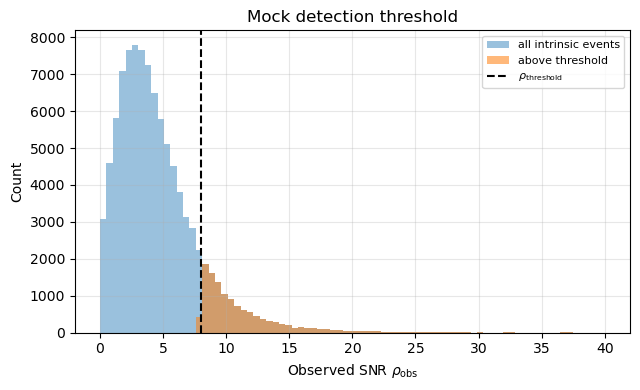

Saved figure to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/mock_detection_snr__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.png


In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))

bins = np.linspace(0.0, max(40.0, np.percentile(rho_obs, 99.5)), 80)
ax.hist(rho_obs, bins=bins, alpha=0.45, label="all intrinsic events")
ax.hist(rho_obs[detected_mask], bins=bins, alpha=0.55, label="above threshold")
ax.axvline(rho_threshold, color="black", lw=1.5, ls="--", label=r"$\rho_{\rm threshold}$")

ax.set_xlabel(r"Observed SNR $\rho_{\rm obs}$")
ax.set_ylabel("Count")
ax.set_title("Mock detection threshold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
figure_path = figures_dir / f"mock_detection_snr__{eos_tag}__{pop_tag}__{detpe_tag}.png"
fig.savefig(figure_path, dpi=200)
plt.show()

print(f"Saved figure to {figure_path}")


## Diagnostic plot: PE residuals


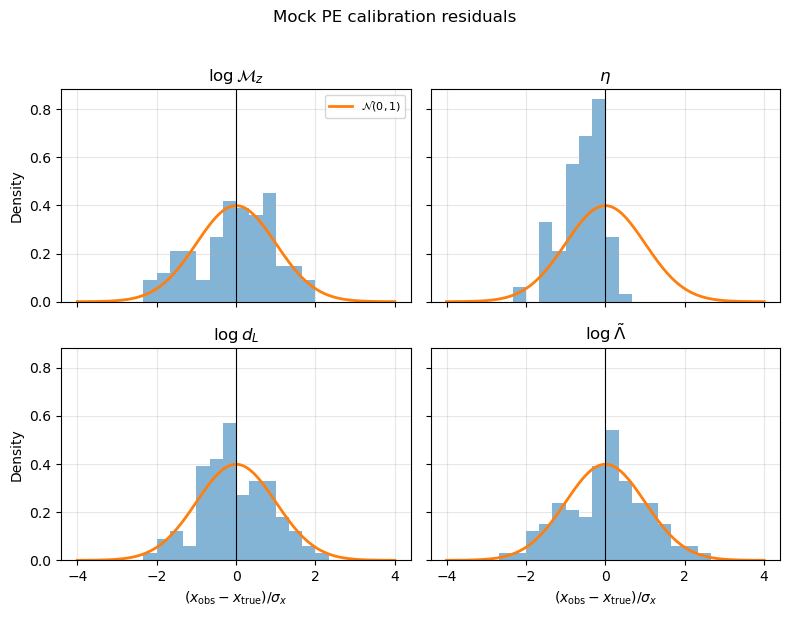

Saved figure to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/mock_pe_residuals__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.png


In [15]:
residuals = [
    (obs_log_mchirp - true_log_mchirp) / sigma_log_mchirp,
    (obs_eta - true_eta) / sigma_eta,
    (obs_log_dl - true_log_dl) / sigma_log_dl,
    (obs_log_lambdatilde - true_log_lambdatilde) / sigma_log_lambdatilde,
]

labels = [
    r"$\log\mathcal{M}_z$",
    r"$\eta$",
    r"$\log d_L$",
    r"$\log\tilde{\Lambda}$",
]

x = np.linspace(-4.0, 4.0, 500)
normal_pdf = np.exp(-0.5 * x**2) / np.sqrt(2.0 * np.pi)

fig, axes = plt.subplots(2, 2, figsize=(8.0, 6.0), sharex=True, sharey=True)

for ax, residual, label in zip(axes.ravel(), residuals, labels):
    ax.hist(residual, bins=np.linspace(-4.0, 4.0, 25), density=True, alpha=0.55)
    ax.plot(x, normal_pdf, lw=2.0, label=r"$\mathcal{N}(0,1)$")
    ax.axvline(0.0, color="black", lw=0.8)
    ax.set_title(label)
    ax.grid(alpha=0.3)

axes[0, 0].set_ylabel("Density")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_xlabel(r"$(x_{\rm obs}-x_{\rm true})/\sigma_x$")
axes[1, 1].set_xlabel(r"$(x_{\rm obs}-x_{\rm true})/\sigma_x$")
axes[0, 0].legend(fontsize=8)

fig.suptitle("Mock PE calibration residuals", y=1.02)
fig.tight_layout()
figure_path = figures_dir / f"mock_pe_residuals__{eos_tag}__{pop_tag}__{detpe_tag}.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to {figure_path}")


## Diagnostic plot: injection coverage in observed space


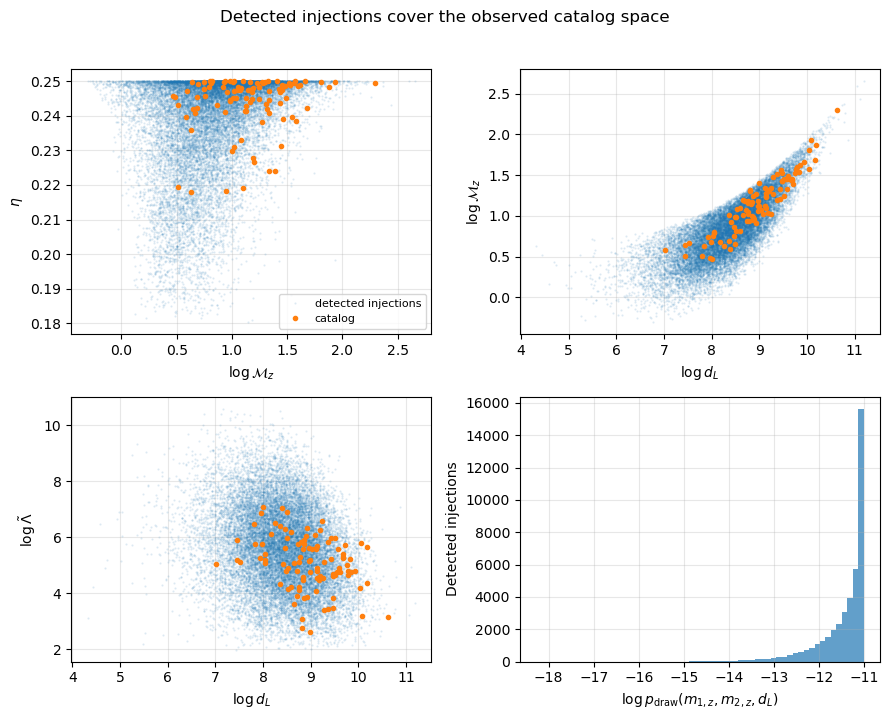

Saved figure to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/injection_coverage_observed_space__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871.png


In [16]:
det_log_mchirp = np.log(mchirp_det[idx])
det_eta = eta[idx]
det_log_dl = np.log(d_l[idx])
det_log_lambdatilde = np.log(lambda_tilde[idx])

inj_log_mchirp = np.log(inj_mchirp_det[inj])
inj_eta_det = inj_eta[inj]
inj_log_dl = np.log(inj_d_l[inj])
inj_log_lambdatilde = np.log(inj_lambda_tilde[inj])

max_points = min(20_000, len(inj_log_mchirp))
plot_inj_idx = rng.choice(len(inj_log_mchirp), size=max_points, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.0))

ax = axes[0, 0]
ax.plot(inj_log_mchirp[plot_inj_idx], inj_eta_det[plot_inj_idx], ".", ms=1.0, alpha=0.15, label="detected injections")
ax.plot(det_log_mchirp, det_eta, "o", ms=3.0, label="catalog")
ax.set_xlabel(r"$\log\mathcal{M}_z$")
ax.set_ylabel(r"$\eta$")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(inj_log_dl[plot_inj_idx], inj_log_mchirp[plot_inj_idx], ".", ms=1.0, alpha=0.15)
ax.plot(det_log_dl, det_log_mchirp, "o", ms=3.0)
ax.set_xlabel(r"$\log d_L$")
ax.set_ylabel(r"$\log\mathcal{M}_z$")
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(inj_log_dl[plot_inj_idx], inj_log_lambdatilde[plot_inj_idx], ".", ms=1.0, alpha=0.15)
ax.plot(det_log_dl, det_log_lambdatilde, "o", ms=3.0)
ax.set_xlabel(r"$\log d_L$")
ax.set_ylabel(r"$\log\tilde{\Lambda}$")
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(log_p_draw_det[inj], bins=60, alpha=0.7)
ax.set_xlabel(r"$\log p_{\rm draw}(m_{1,z},m_{2,z},d_L)$")
ax.set_ylabel("Detected injections")
ax.grid(alpha=0.3)

fig.suptitle("Detected injections cover the observed catalog space", y=1.02)
fig.tight_layout()
figure_path = figures_dir / f"injection_coverage_observed_space__{eos_tag}__{pop_tag}__{detpe_tag}__{inj_tag}.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to {figure_path}")
